In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df = df[['BMI','혈당','나이','임신횟수','혈압','가족력지표','피부두께','인슐린','당뇨']]
df

,BMI,혈당,나이,임신횟수,혈압,가족력지표,피부두께,인슐린,당뇨
0,33.6,148.0,50,6,72.0,0.627,35.0,159.0,1
1,26.6,85.0,31,1,66.0,0.351,29.0,95.0,0
2,23.3,183.0,32,8,64.0,0.672,32.0,159.0,1
3,28.1,89.0,21,1,66.0,0.167,23.0,94.0,0
4,43.1,137.0,33,0,40.0,2.288,35.0,168.0,1
...,...,...,...,...,...,...,...,...,...
713,32.9,101.0,63,10,76.0,0.171,48.0,180.0,0
714,36.8,122.0,27,2,70.0,0.340,27.0,95.0,0
715,26.2,121.0,30,5,72.0,0.245,23.0,112.0,0
716,30.1,126.0,47,1,60.0,0.349,32.0,159.0,1


In [3]:
# train과 test 분리
data = df.iloc[:,:-1]
target = df.iloc[:,-1]

train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    stratify=target
)

# 정규화
ss = StandardScaler()
train_scaled = ss.fit_transform(train_data)
test_scaled = ss.transform(test_data)

print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

train_scaled

(538, 8)
(180, 8)
(538,)
(180,)


array([[ 2.24240641,  1.8274651 ,  2.14948705, ...,  2.14461931,
         0.44159045,  2.80215884],
       [ 0.65014362, -0.38605208,  0.00335084, ..., -0.65198478,
         1.78313681, -0.89814315],
       [ 0.69607428,  2.30422264,  0.26088719, ..., -0.19940934,
        -0.77799715,  1.53626605],
       ...,
       [ 1.10945019, -0.55632263, -0.16834005, ..., -0.39916678,
         0.44159045,  0.73777983],
       [-0.8808783 ,  2.54260142,  2.92209609, ...,  0.24692367,
        -0.16820335, -0.50863768],
       [ 1.24724216,  2.09989798, -0.94094909, ...,  2.45361909,
         1.66117805,  3.3474665 ]], shape=(538, 8))

In [4]:
scoring_list = ['accuracy', 'precision', 'recall', 'f1']

k_list = []
for i in range(3, 100, 2):
    k_list.append(i)

best_k_dic = {}

for s in scoring_list:
    mean_scores = []
    std_scores = []

    for k in k_list:
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        scores = cross_val_score(
            knn,
            train_scaled,
            train_target,
            cv=6,
            n_jobs=-1,
            scoring=s
        )
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

    best_i = int(np.argmax(mean_scores))
    best_k = k_list[best_i]

    best_k_dic[s] = {
        "best_k": best_k,
        "best_score_mean": mean_scores[best_i],
        "best_score_std": std_scores[best_i]
    }

print(best_k_dic)

{'accuracy': {'best_k': 3, 'best_score_mean': np.float64(0.8495422388680814), 'best_score_std': np.float64(0.02237429864459124)}, 'precision': {'best_k': 39, 'best_score_mean': np.float64(0.8069240114467501), 'best_score_std': np.float64(0.04022417132568881)}, 'recall': {'best_k': 3, 'best_score_mean': np.float64(0.7599616858237548), 'best_score_std': np.float64(0.03940823032083169)}, 'f1': {'best_k': 3, 'best_score_mean': np.float64(0.7707781276592246), 'best_score_std': np.float64(0.032896418462916195)}}


> 정확도와 재현율, f1 점수가 가장 높은 k=3이 최적의 k 값으로 판단됨.     
표준편차도 크지 않기 때문에 안정적인 성능을 보임.    
정밀도의 경우 당뇨라고 예측한 것 중 얼마나 맞는지를 뜻하므로 k가 커질수록 신뢰도가 감소할 수 있음.

In [5]:
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn.fit(train_scaled, train_target)

train_pred = knn.predict(train_scaled)
test_pred = knn.predict(test_scaled)

def print_score(target, pred, name):
    print(f"\n===== {name} =====")
    print("Accuracy :", metrics.accuracy_score(target, pred))
    print("Precision:", metrics.precision_score(target, pred))
    print("Recall   :", metrics.recall_score(target, pred))
    print("F1 Score :", metrics.f1_score(target, pred))
    print("Confusion Matrix\n", metrics.confusion_matrix(target, pred))
    print(metrics.classification_report(target, pred))

print_score(train_target, train_pred, "TRAIN")
print_score(test_target, test_pred, "TEST")


===== TRAIN =====
Accuracy : 0.9052044609665427
Precision: 0.8636363636363636
Recall   : 0.8491620111731844
F1 Score : 0.856338028169014
Confusion Matrix
 [[335  24]
 [ 27 152]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       359
           1       0.86      0.85      0.86       179

    accuracy                           0.91       538
   macro avg       0.89      0.89      0.89       538
weighted avg       0.90      0.91      0.91       538


===== TEST =====
Accuracy : 0.8888888888888888
Precision: 0.7777777777777778
Recall   : 0.9333333333333333
F1 Score : 0.8484848484848485
Confusion Matrix
 [[104  16]
 [  4  56]]
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       120
           1       0.78      0.93      0.85        60

    accuracy                           0.89       180
   macro avg       0.87      0.90      0.88       180
weighted avg       0.90      0.89      0.89

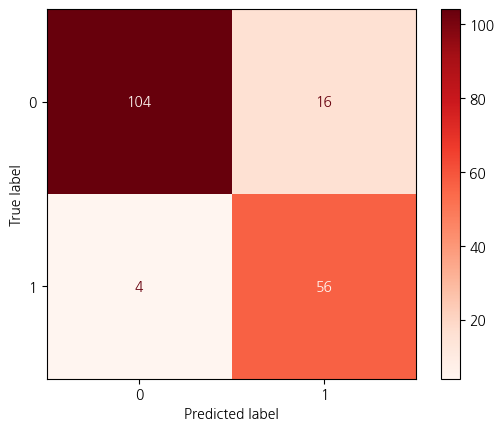

In [6]:
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=metrics.confusion_matrix(test_target, test_pred),
    display_labels=sorted(test_target.unique())
)
disp.plot(cmap=plt.cm.Reds)

plt.show()

> KNN(k=3) 모델은 Test 데이터에서 Accuracy 0.889, Recall 0.933, F1-score 0.848을 나타냈다.    
특히 실제 당뇨 환자 60명 중 56명을 정확하게 구별했고, 이는 당뇨 환자 구별에 특히 높은 성능을 보였음을 의미한다.    
의료 목적으로 사용할 때 당뇨인 환자를 구별하는 것이 더 중요하므로 좋은 결과로 보인다.    
Train과 Test 간 성능 차이도 크지 않아 과적합은 나타나지 않았다.    
macro avg, weighted avg 비교 결과 데이터 개수의 차이도 큰 영향을 주지 않았다.

------------------------
-------------------
-----------

In [7]:
# 앱으로 만들어야 하므로 유저가 쉽게 입력 할 수 있는 것들만 피쳐로 선정해서 해보는 것으로 함
df = df[['BMI','나이','가족력지표','피부두께', '혈당','당뇨']]
data = df.iloc[:,:-1]
target = df.iloc[:,-1]
data['Waist_Risk_Factor'] = (data['BMI'] ** 1.2) / 10
data['Abdominal_Glucose_Risk'] = (data['혈당'] * data['Waist_Risk_Factor']) / 100
data['가족력로그'] = np.log10(data['가족력지표'])
data.drop(['Waist_Risk_Factor','가족력지표'],axis = 1,inplace=True)
train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    stratify=target
)

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)

def calculate_pedigree_score(has_parents=False, has_siblings=False, has_grandparents=False):
    """
    유저의 체크 항목을 기반으로 당뇨 가족력지표(Pedigree Function)를 계산합니다.
    """
    # 1. 기본 점수 (가족력이 없는 경우의 최소치)
    score = 0.08
    
    # 2. 직계 가족 가중치 합산
    if has_parents:
        score += 0.35 
        
    if has_siblings:
        score += 0.25  # 형제/자매 중 있는 경우
        
    if has_grandparents:
        score += 0.15  # 조부모님 중 있는 경우
        
    # np.log1p는 ln(1 + x)를 계산하여 값의 왜곡을 줄여줍니다.
    log_score = np.log1p(score)
    
    return round(log_score, 4)

user_score = calculate_pedigree_score(has_parents=True, has_siblings=False, has_grandparents=True)

print(f"유저의 최종 입력용 가족력 점수: {user_score}")

def get_estimated_skin_thickness(bmi):
    # 실제 Pima 데이터셋 기준 대략적인 평균 계수값 적용
    # 데이터마다 조금 다르지만 보통 기울기는 0.8~1.1 사이로 나옵니다.
    slope = 0.95 
    intercept = -2.5
    
    # 수식 적용
    predicted_thickness = (slope * bmi) + intercept
    
    # 최소값 방어 (피부두께가 음수가 나올 수는 없으므로)
    return round(max(predicted_thickness, 5.0), 2)

scoring_list = ['accuracy', 'precision', 'recall', 'f1']

k_list = []
for i in range(3, 200, 2):
    k_list.append(i)

best_k_dic = {}

for s in scoring_list:
    mean_scores = []
    std_scores = []

    for k in k_list:
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        scores = cross_val_score(
            knn,
            train_scaled,
            train_target,
            cv=6,
            n_jobs=-1,
            scoring=s
        )
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

    best_i = int(np.argmax(mean_scores))
    best_k = k_list[best_i]

    best_k_dic[s] = {
        "best_k": best_k,
        "best_score_mean": mean_scores[best_i],
        "best_score_std": std_scores[best_i]
    }

print(best_k_dic)

유저의 최종 입력용 가족력 점수: 0.4574
{'accuracy': {'best_k': 17, 'best_score_mean': np.float64(0.7919267582188931), 'best_score_std': np.float64(0.03266792305520813)}, 'precision': {'best_k': 199, 'best_score_mean': np.float64(0.8168843826738562), 'best_score_std': np.float64(0.055310454321952265)}, 'recall': {'best_k': 13, 'best_score_mean': np.float64(0.6256704980842912), 'best_score_std': np.float64(0.0890555314685645)}, 'f1': {'best_k': 17, 'best_score_mean': np.float64(0.6623681269180599), 'best_score_std': np.float64(0.06493688823689144)}}



===== TRAIN =====
Accuracy : 0.8011152416356877
Precision: 0.7278481012658228
Recall   : 0.6424581005586593
F1 Score : 0.6824925816023739
Confusion Matrix
 [[316  43]
 [ 64 115]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       359
           1       0.73      0.64      0.68       179

    accuracy                           0.80       538
   macro avg       0.78      0.76      0.77       538
weighted avg       0.80      0.80      0.80       538


===== TEST =====
Accuracy : 0.8388888888888889
Precision: 0.7818181818181819
Recall   : 0.7166666666666667
F1 Score : 0.7478260869565218
Confusion Matrix
 [[108  12]
 [ 17  43]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       120
           1       0.78      0.72      0.75        60

    accuracy                           0.84       180
   macro avg       0.82      0.81      0.81       180
weighted avg       0.84      0.84      0.8

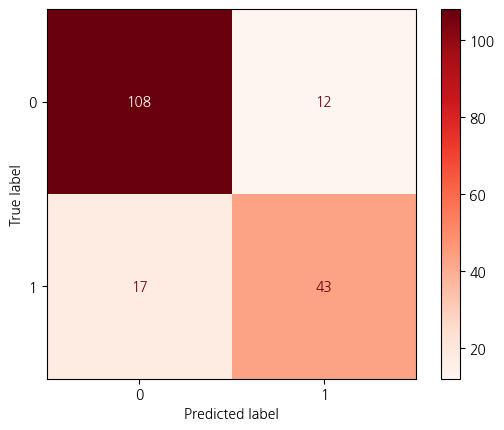

In [8]:
knn = KNeighborsClassifier(n_neighbors=17, n_jobs=-1)
knn.fit(train_scaled, train_target)

train_pred = knn.predict(train_scaled)
test_pred = knn.predict(test_scaled)

def print_score(target, pred, name):
    print(f"\n===== {name} =====")
    print("Accuracy :", metrics.accuracy_score(target, pred))
    print("Precision:", metrics.precision_score(target, pred))
    print("Recall   :", metrics.recall_score(target, pred))
    print("F1 Score :", metrics.f1_score(target, pred))
    print("Confusion Matrix\n", metrics.confusion_matrix(target, pred))
    print(metrics.classification_report(target, pred))

print_score(train_target, train_pred, "TRAIN")
print_score(test_target, test_pred, "TEST")

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=metrics.confusion_matrix(test_target, test_pred),
    display_labels=sorted(test_target.unique())
)
disp.plot(cmap=plt.cm.Reds)

plt.show()


===== TRAIN =====
Accuracy : 0.8122676579925651
Precision: 0.7407407407407407
Recall   : 0.6703910614525139
F1 Score : 0.7038123167155426
Confusion Matrix
 [[317  42]
 [ 59 120]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       359
           1       0.74      0.67      0.70       179

    accuracy                           0.81       538
   macro avg       0.79      0.78      0.78       538
weighted avg       0.81      0.81      0.81       538


===== TEST =====
Accuracy : 0.8055555555555556
Precision: 0.711864406779661
Recall   : 0.7
F1 Score : 0.7058823529411765
Confusion Matrix
 [[103  17]
 [ 18  42]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       120
           1       0.71      0.70      0.71        60

    accuracy                           0.81       180
   macro avg       0.78      0.78      0.78       180
weighted avg       0.80      0.81      0.81       180



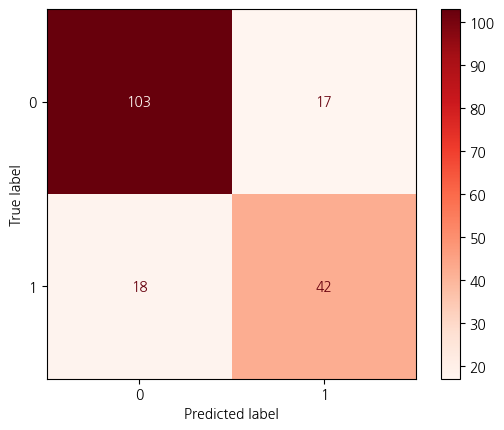

In [9]:
knn = KNeighborsClassifier(n_neighbors=13, n_jobs=-1)
knn.fit(train_scaled, train_target)

train_pred = knn.predict(train_scaled)
test_pred = knn.predict(test_scaled)

def print_score(target, pred, name):
    print(f"\n===== {name} =====")
    print("Accuracy :", metrics.accuracy_score(target, pred))
    print("Precision:", metrics.precision_score(target, pred))
    print("Recall   :", metrics.recall_score(target, pred))
    print("F1 Score :", metrics.f1_score(target, pred))
    print("Confusion Matrix\n", metrics.confusion_matrix(target, pred))
    print(metrics.classification_report(target, pred))

print_score(train_target, train_pred, "TRAIN")
print_score(test_target, test_pred, "TEST")

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=metrics.confusion_matrix(test_target, test_pred),
    display_labels=sorted(test_target.unique())
)
disp.plot(cmap=plt.cm.Reds)

plt.show()